## Импорт библиотек и загрузка набора данных

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import sklearn.impute 
import sklearn.preprocessing 
import matplotlib_inline.backend_inline
# from IPython.display import set_matplotlib_formats


In [2]:
sns.set(style="ticks") 
 
data=pd.read_csv("Video_Games_Sales_as_at_22_Dec_2016.csv") 
matplotlib_inline.backend_inline.set_matplotlib_formats("retina") 


##  Первые 5 строк датасета 

In [3]:
data.head() 

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
total_count = data.shape[0] 
print('Всего строк: {}'.format(total_count))

Всего строк: 16719


##  Типы колонок

In [5]:
data.dtypes 

Name                   str
Platform               str
Year_of_Release    float64
Genre                  str
Publisher              str
NA_Sales           float64
EU_Sales           float64
JP_Sales           float64
Other_Sales        float64
Global_Sales       float64
Critic_Score       float64
Critic_Count       float64
User_Score             str
User_Count         float64
Developer              str
Rating                 str
dtype: object

## Размер набора данных

In [6]:
data.shape 

(16719, 16)

## Обработка пропусков данных

In [7]:
data.isnull().sum() 

Name                  2
Platform              0
Year_of_Release     269
Genre                 2
Publisher            54
NA_Sales              0
EU_Sales              0
JP_Sales              0
Other_Sales           0
Global_Sales          0
Critic_Score       8582
Critic_Count       8582
User_Score         6704
User_Count         9129
Developer          6623
Rating             6769
dtype: int64

### 1) Удаление колонок, содержащие пустые значения

In [8]:
data_new_1 = data.dropna(axis=1, how='any') 
(data.shape, data_new_1.shape)

((16719, 16), (16719, 6))

In [9]:
data_new_1.columns 

Index(['Platform', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales',
       'Global_Sales'],
      dtype='str')

In [10]:
data_new_1.head()

,Platform,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,Wii,41.36,28.96,3.77,8.45,82.53
1,NES,29.08,3.58,6.81,0.77,40.24
2,Wii,15.68,12.76,3.79,3.29,35.52
3,Wii,15.61,10.93,3.28,2.95,32.77
4,GB,11.27,8.89,10.22,1.00,31.37


### 2) Удаление строк, содержащие пустые значения

In [11]:
data_new_2 = data.dropna(axis=0, how='any') 
(data.shape, data_new_2.shape) 

((16719, 16), (6825, 16))

### 3) Найдем пропуски в данных в процентном соотношении

In [12]:
for col in data.columns:
    pct_missing = np.mean(data[col].isnull())
    print('{} - {}%'.format(col, round(pct_missing*100))) 


Name - 0%
Platform - 0%
Year_of_Release - 2%
Genre - 0%
Publisher - 0%
NA_Sales - 0%
EU_Sales - 0%
JP_Sales - 0%
Other_Sales - 0%
Global_Sales - 0%
Critic_Score - 51%
Critic_Count - 51%
User_Score - 40%
User_Count - 55%
Developer - 40%
Rating - 40%


## Работа с заполнение пропусков

<Axes: >

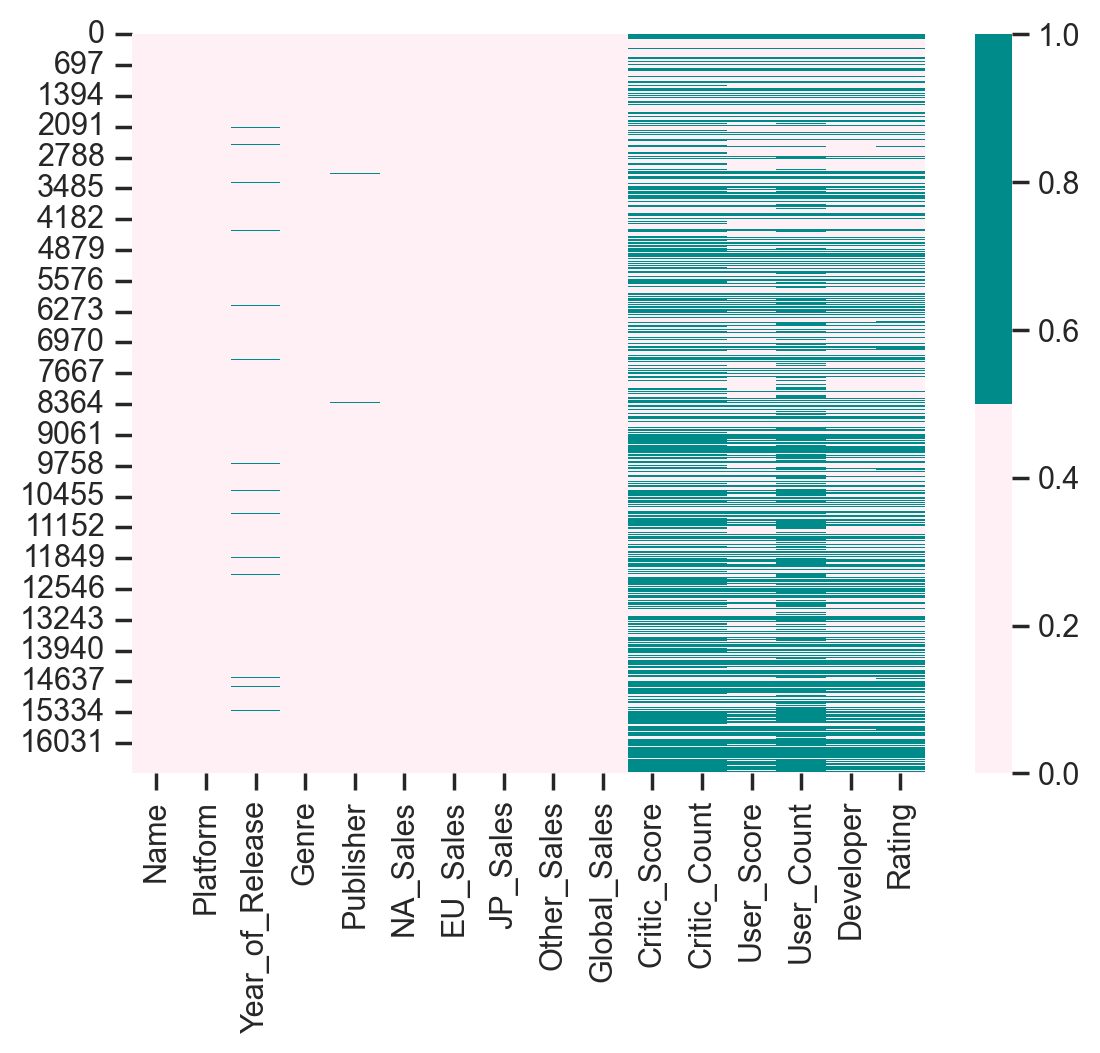

In [13]:
colors = ['#FFF0F5', '#008B8B'] 
sns.heatmap(data[data.columns].isnull(),  
cmap=sns.color_palette(colors)) 

### 1) Заполнение пропусков нулямми

C:\Users\sorok\AppData\Local\Temp\ipykernel_16572\1408924633.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Year_of_Release'].fillna(0))


<Axes: xlabel='Year_of_Release', ylabel='Density'>

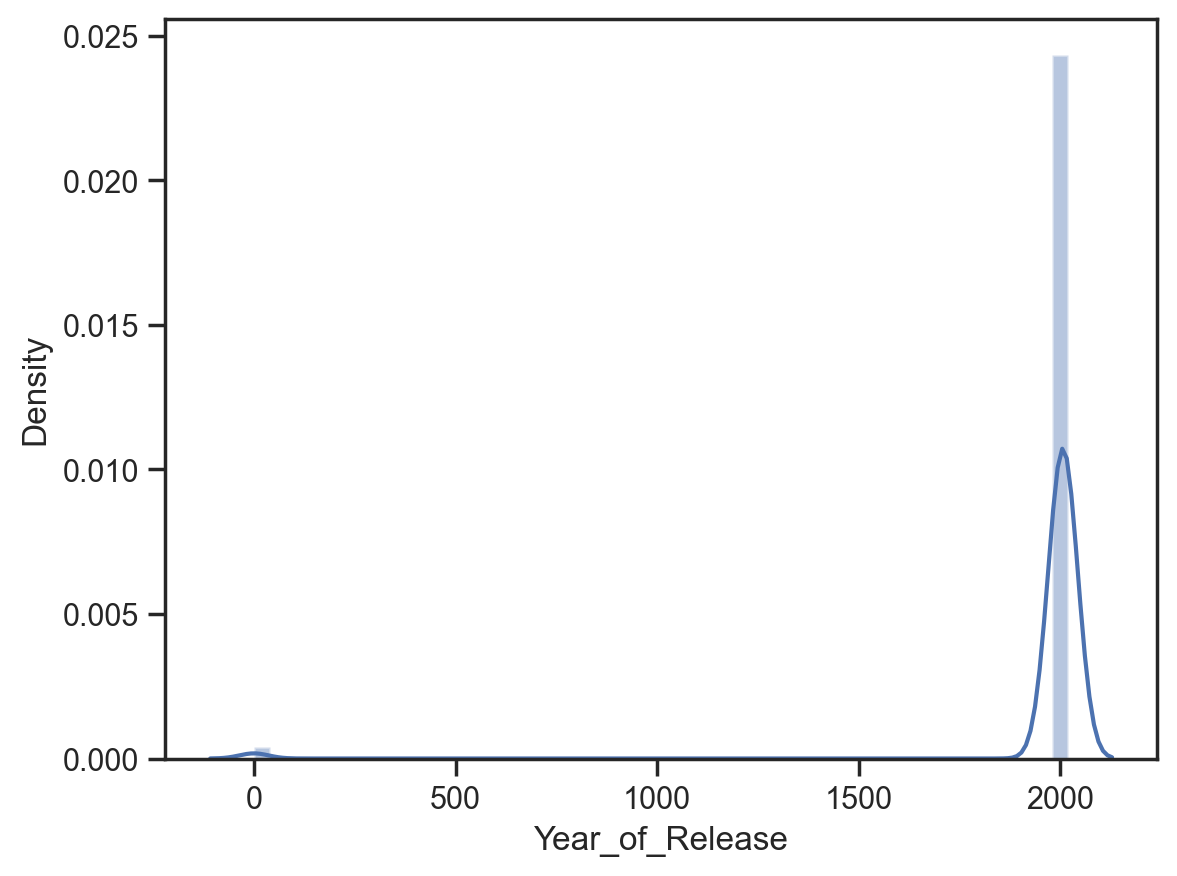

In [14]:
sns.distplot(data['Year_of_Release'].fillna(0)) 

Получаем совершенно не то, что нам нужно 
С помощью класса SimpleImputer можно проводить импьютацию различными показателями центра распределения 

In [15]:
def plot_hist_diff(old_ds, new_ds, cols):
    """
    Разница между распределениями до и после устранения пропусков
    """
    for c in cols:   
        fig = plt.figure()
        ax = fig.add_subplot(111)
        ax.title.set_text('Поле - ' + str(c))
        old_ds[c].hist(bins=50, ax=ax, density=True, color='green')
        new_ds[c].hist(bins=50, ax=ax, color='blue', density=True, alpha=0.5)
        plt.show()


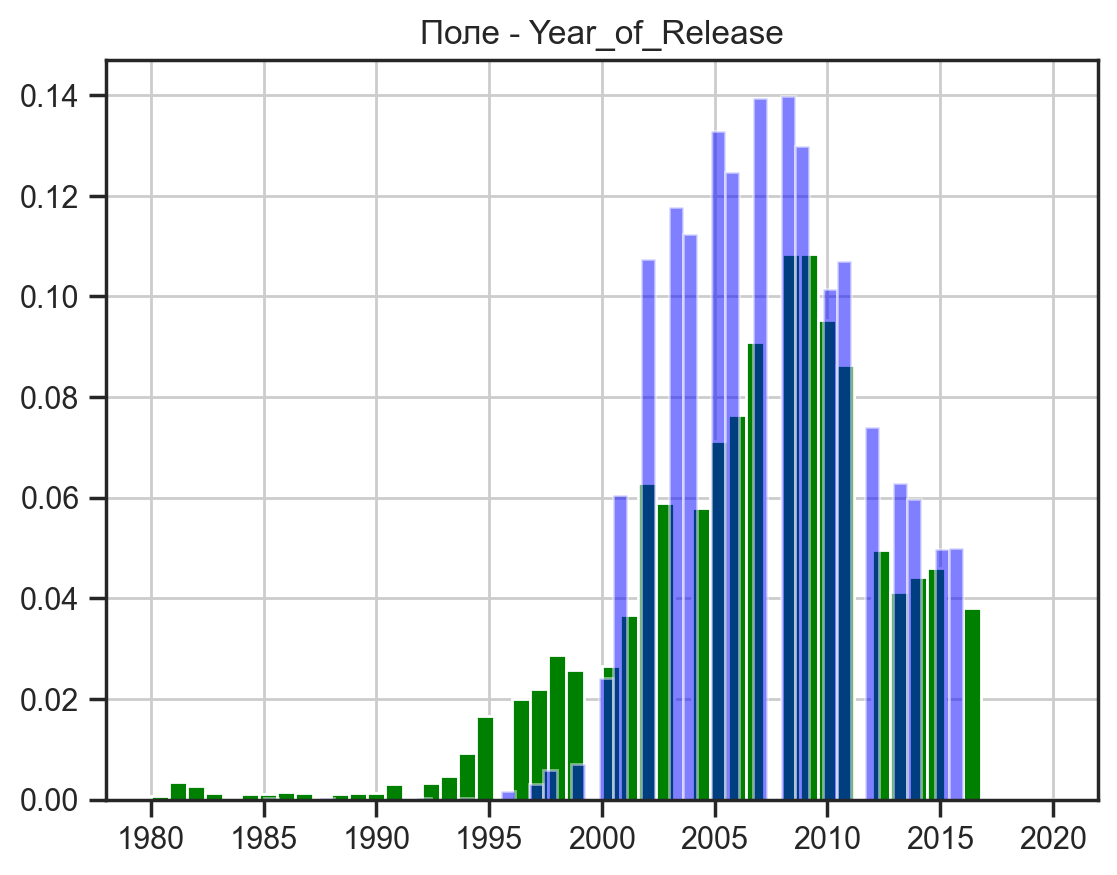

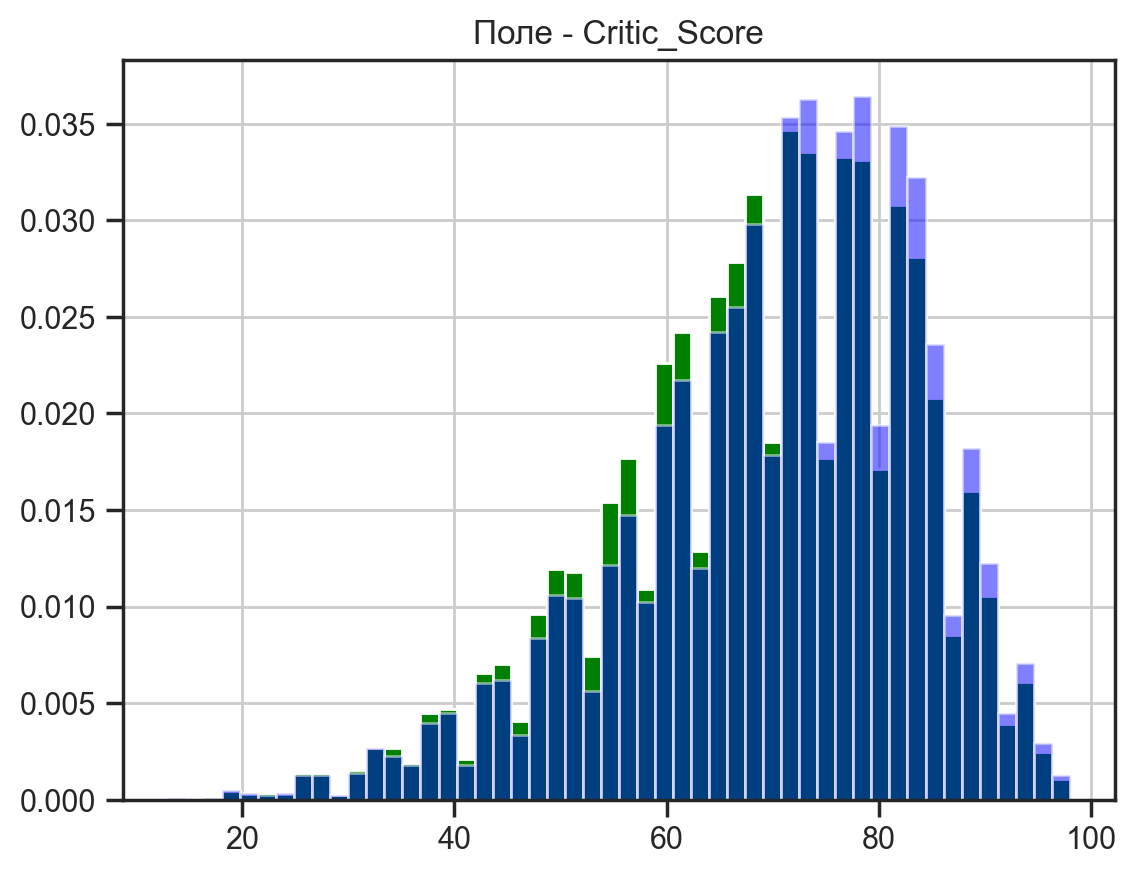

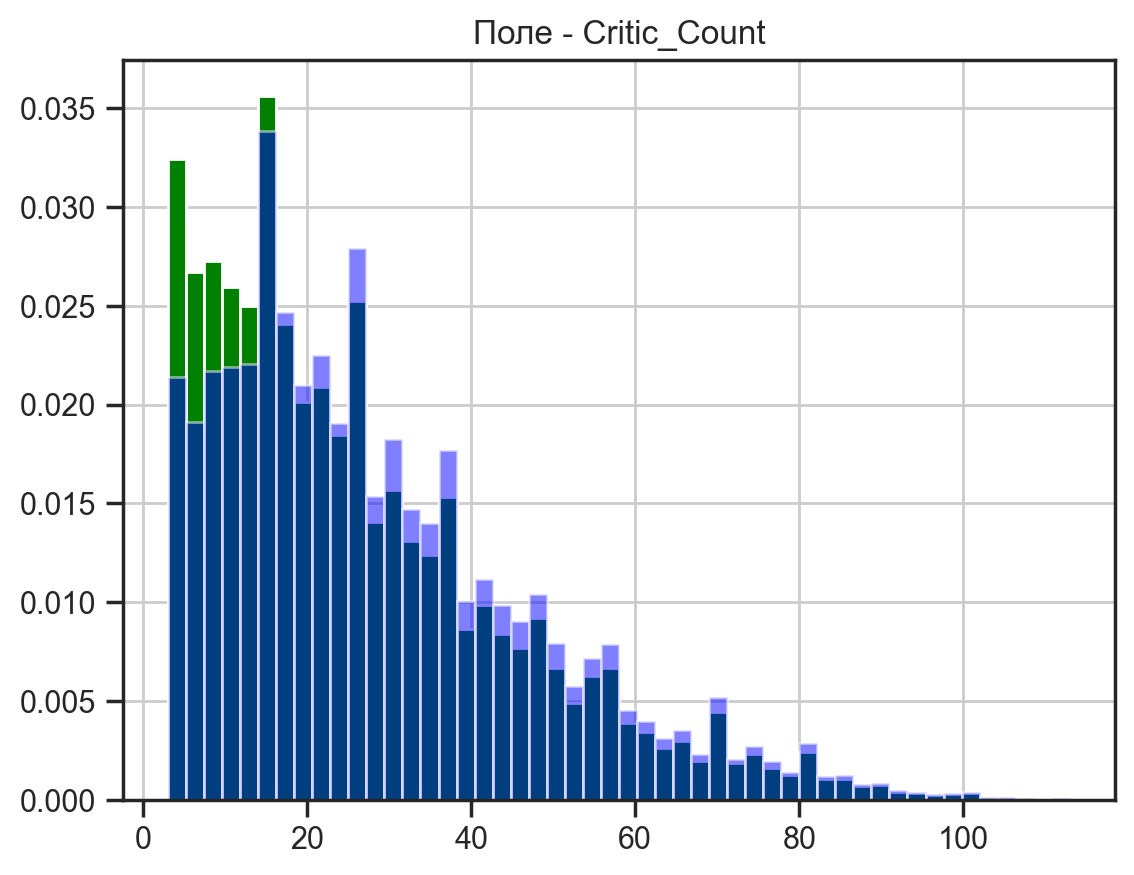

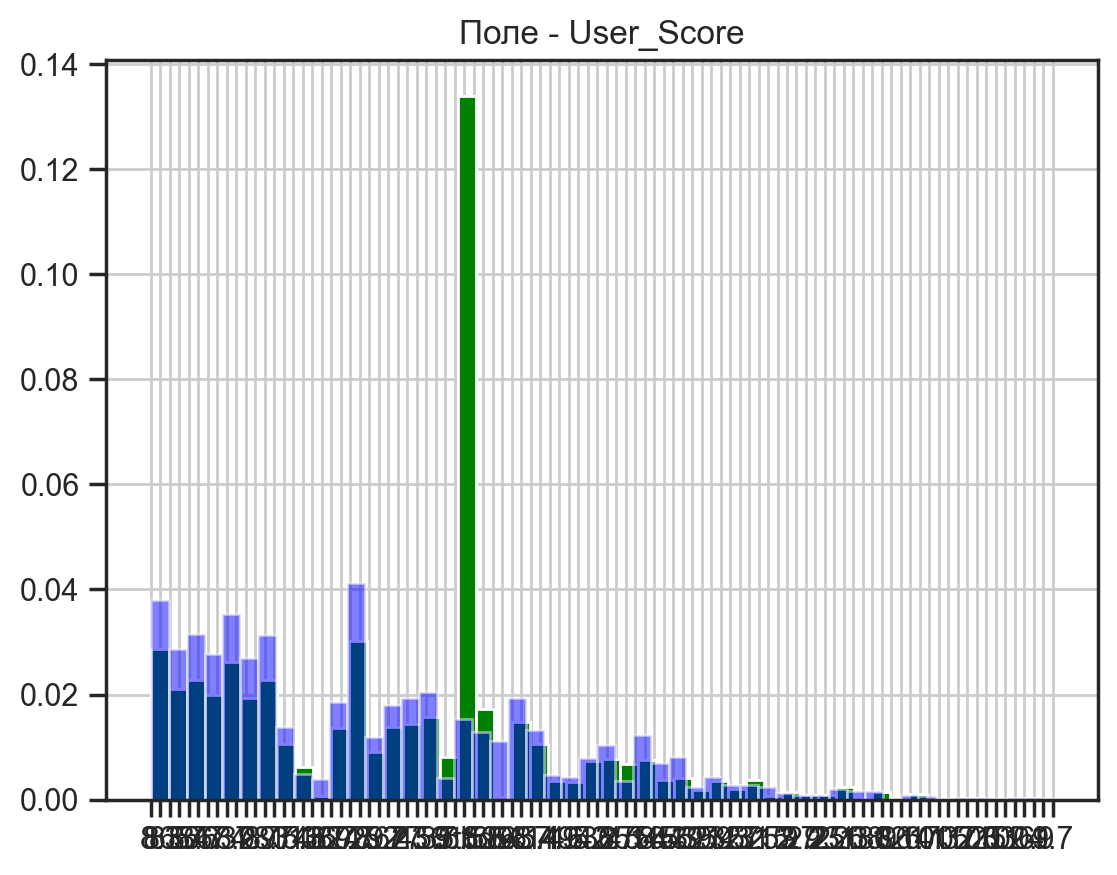

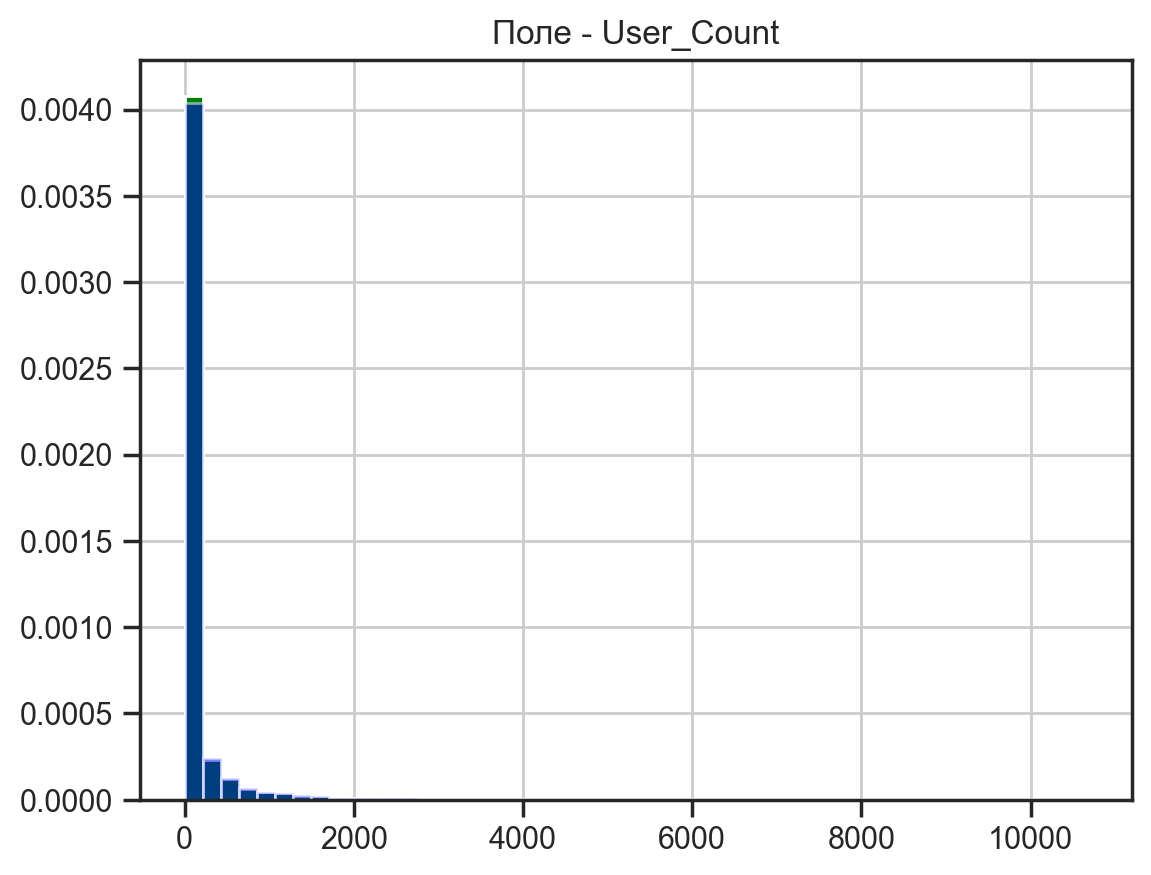

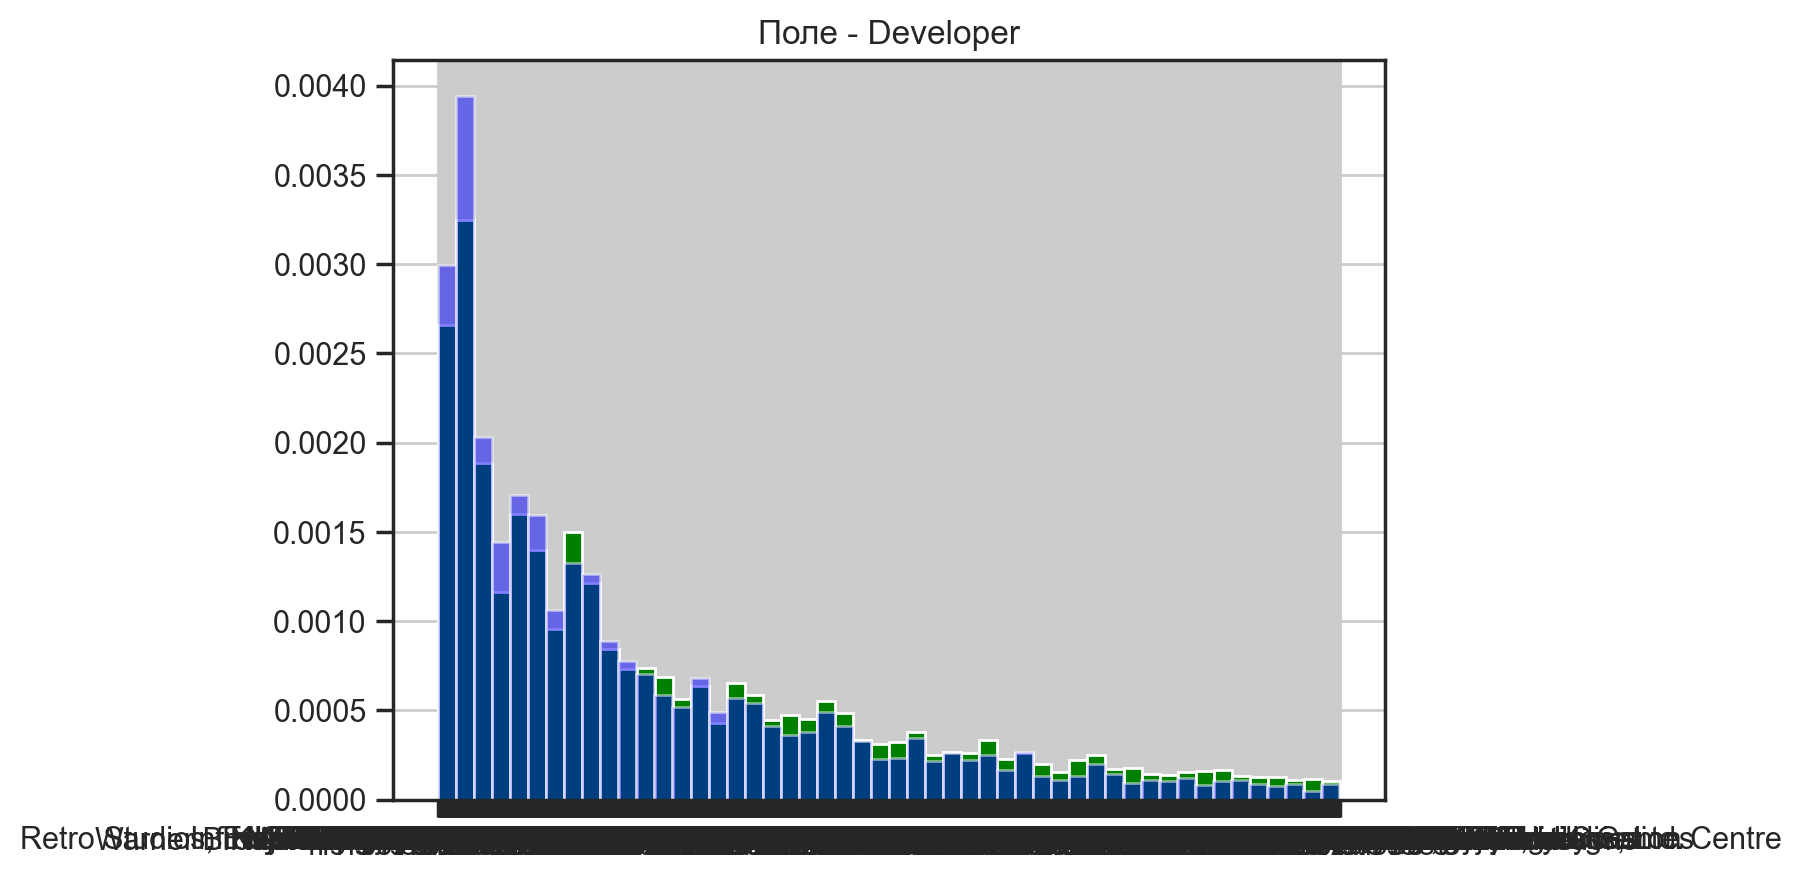

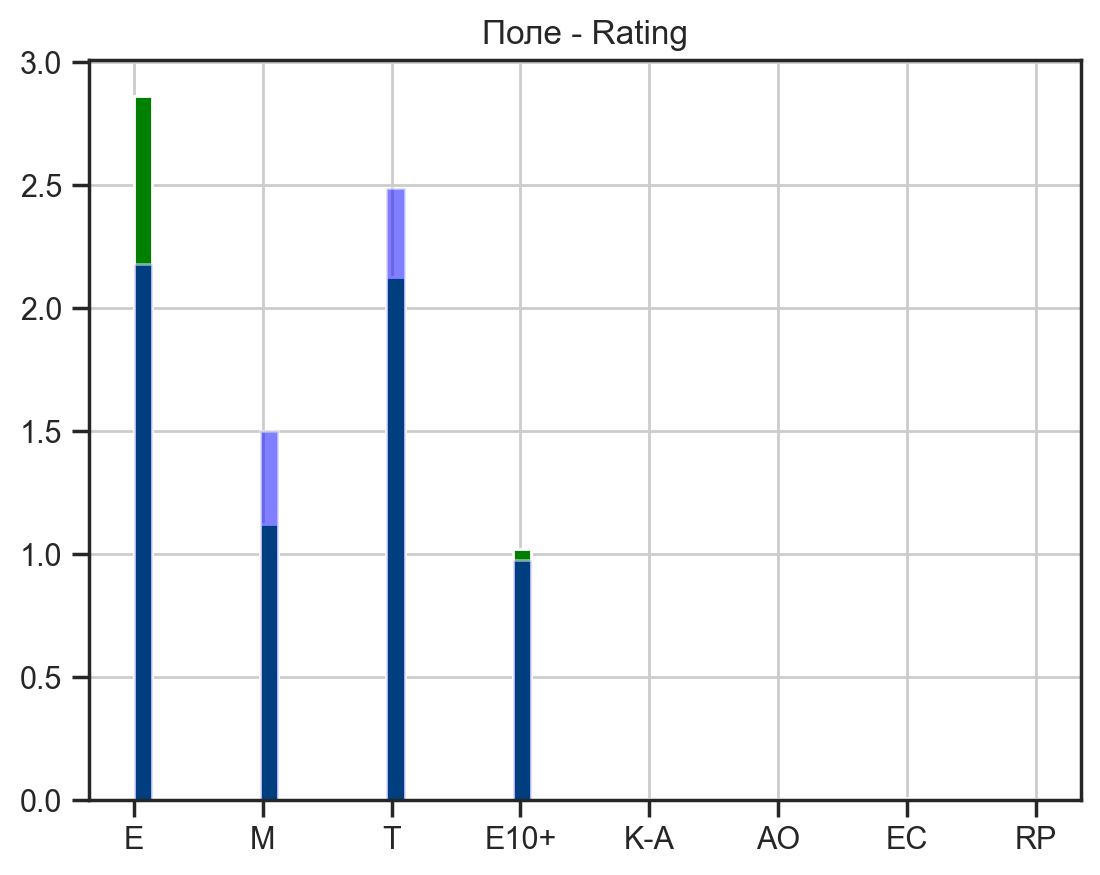

In [16]:
# Колонки для которых удаляются пропуски
hcols_with_na_temp = ['Year_of_Release', 'Critic_Score', 'Critic_Count', 'User_Score', 'User_Count', 'Developer', 'Rating']
plot_hist_diff(data, data_new_2, hcols_with_na_temp)

### 2) Применим заполнение средними значениями

C:\Users\sorok\AppData\Local\Temp\ipykernel_16572\3136282317.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(mean_rate)


<Axes: ylabel='Density'>

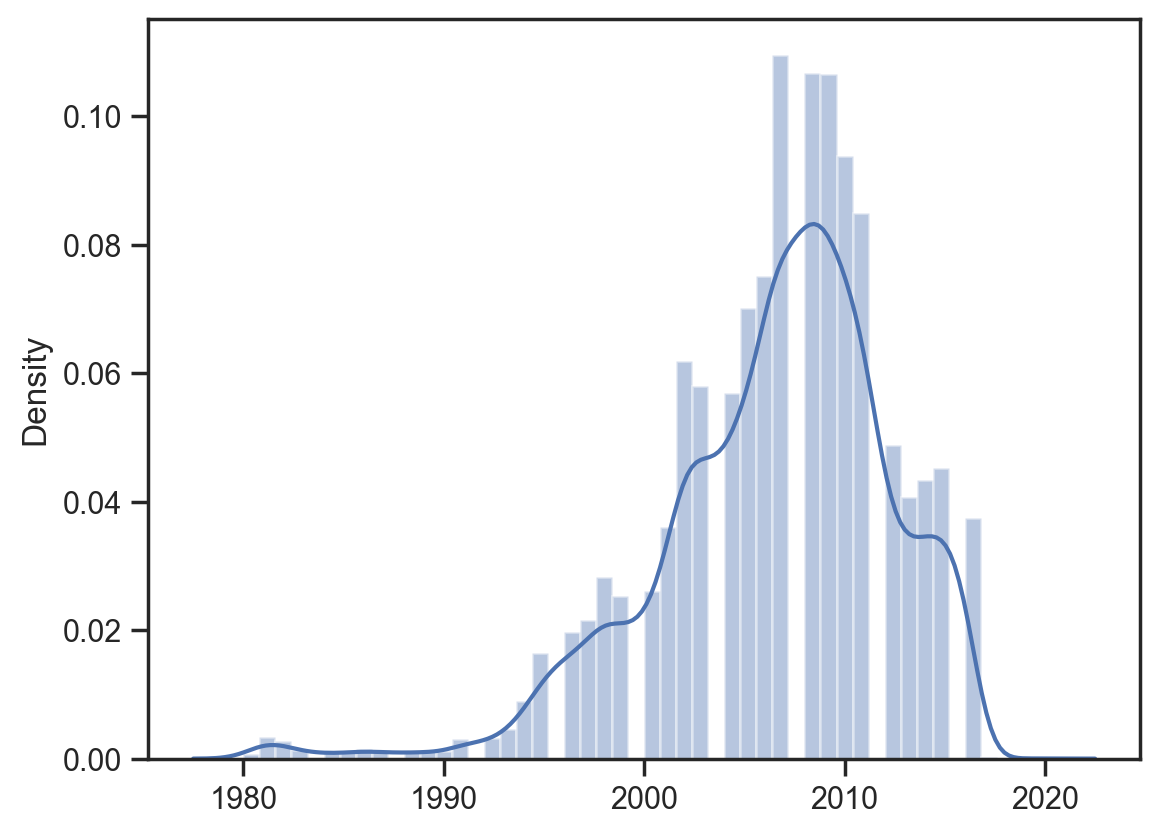

In [17]:
mean=sklearn.impute.SimpleImputer(strategy="mean") # Среднее значение 
mean_rate=mean.fit_transform(data[['Year_of_Release']])
sns.distplot(mean_rate)

### 3) Применение медианного значения

C:\Users\sorok\AppData\Local\Temp\ipykernel_16572\73871808.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(med_rate)


<Axes: ylabel='Density'>

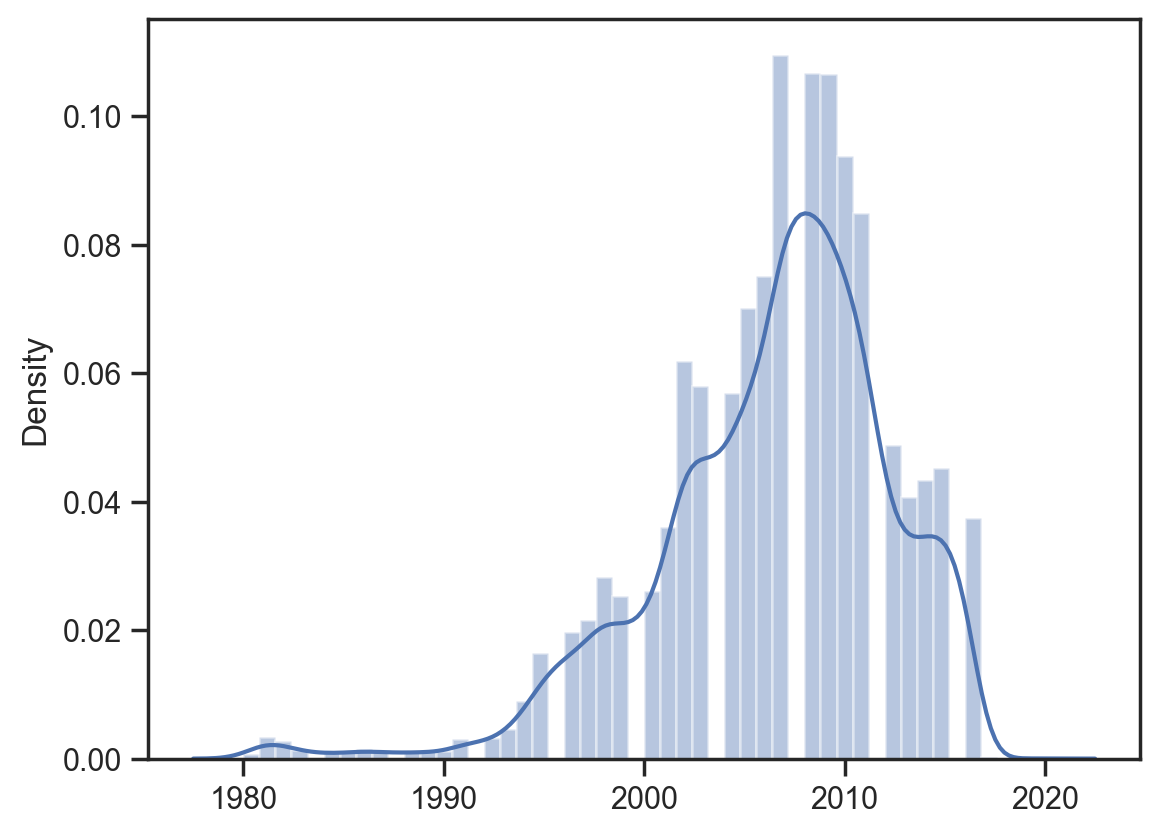

In [18]:
med=sklearn.impute.SimpleImputer(strategy="median") # Медиана  
med_rate=med.fit_transform(data[['Year_of_Release']])
sns.distplot(med_rate) 

### 4) Сравнение сразу нескольких стратеги заполнений данных

In [19]:
from sklearn.impute import MissingIndicator
from sklearn.impute import SimpleImputer


def impute_column(dataset, column, strategy_param, fill_value_param=None):
    """
    Заполнение пропусков в одном признаке
    """
    temp_data = dataset[[column]].values
    size = temp_data.shape[0]
    
    indicator = MissingIndicator()
    mask_missing_values_only = indicator.fit_transform(temp_data)
    
    imputer = SimpleImputer(strategy=strategy_param, fill_value=fill_value_param)
    all_data = imputer.fit_transform(temp_data)
    
    missed_data = temp_data[mask_missing_values_only]
    filled_data = all_data[mask_missing_values_only]
    
    return all_data.reshape((size,)), filled_data, missed_data

In [20]:
def research_impute_numeric_column(dataset, num_column, const_value=None):
    strategy_params = ['mean', 'median', 'most_frequent', 'constant']
    strategy_params_names = ['Среднее', 'Медиана', 'Мода']
    strategy_params_names.append('Константа = ' + str(const_value))
    
    original_temp_data = dataset[[num_column]].values
    size = original_temp_data.shape[0]
    original_data = original_temp_data.reshape((size,))
    
    new_df = pd.DataFrame({'Исходные данные':original_data})

    for i in range(len(strategy_params)):
        strategy = strategy_params[i]
        col_name = strategy_params_names[i]
        if (strategy!='constant') or (strategy == 'constant' and const_value!=None):
            if strategy == 'constant':
                temp_data, _, _ = impute_column(dataset, num_column, strategy, fill_value_param=const_value)
            else:
                temp_data, _, _ = impute_column(dataset, num_column, strategy)
            new_df[col_name] = temp_data
    sns.kdeplot(data=new_df)

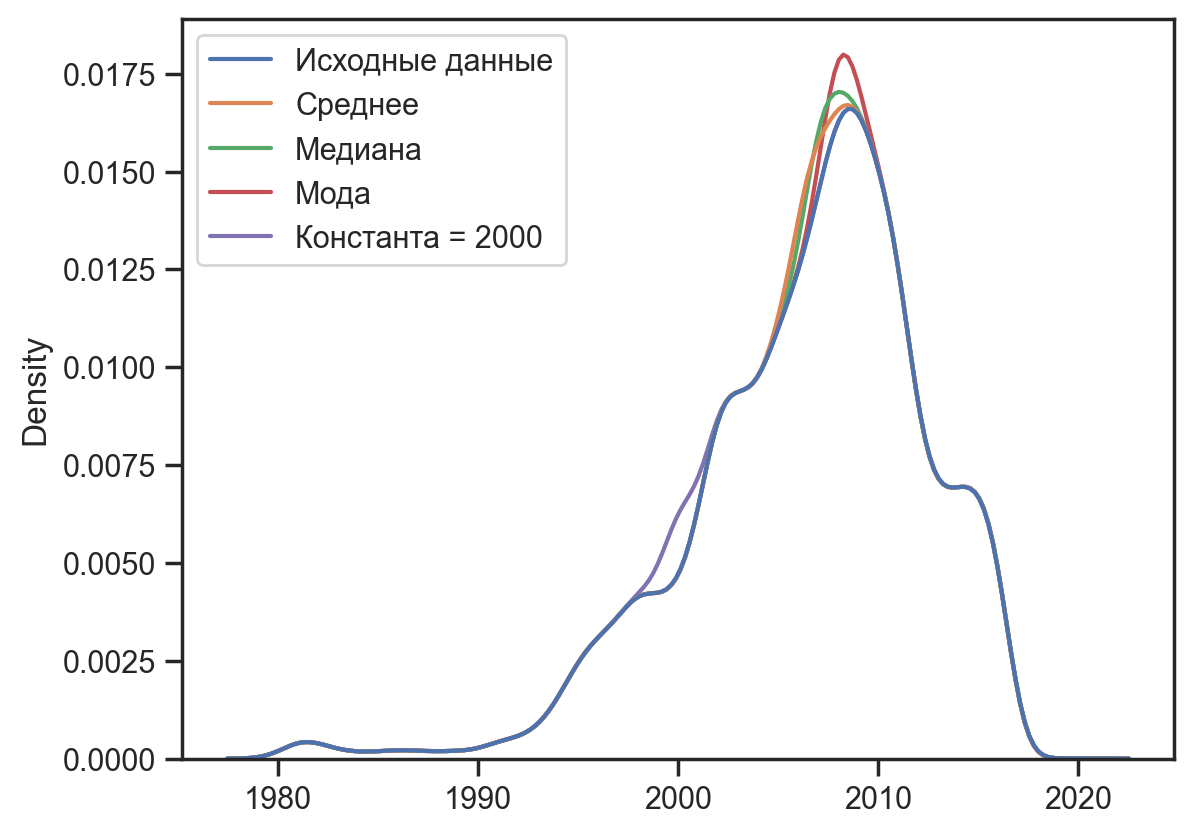

In [21]:
research_impute_numeric_column(data, 'Year_of_Release', 2000)

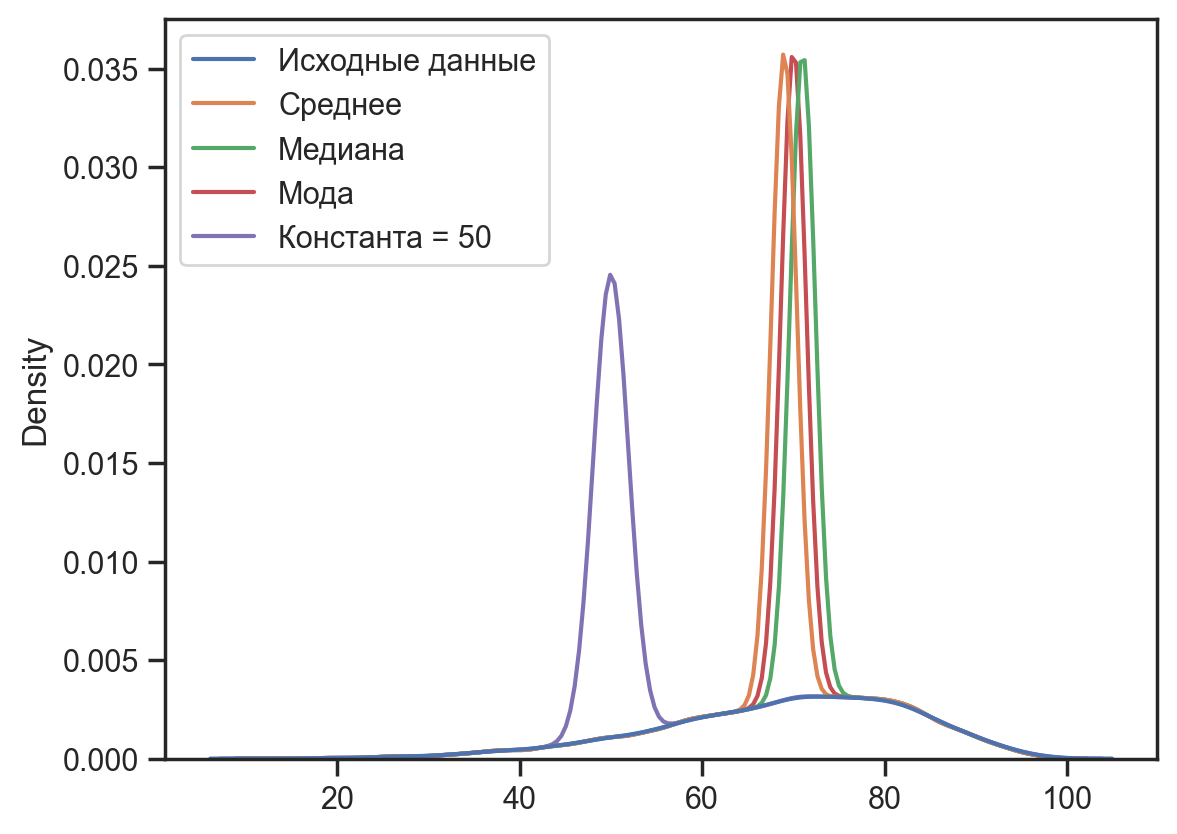

In [22]:
research_impute_numeric_column(data, 'Critic_Score', 50)

### Заполнение "хвостом распределения"

**Для числовых признаков.**

**Допущение:** пропуски распределены НЕ случайным образом. Мы хотим выделить пропущенные значения из остальных значений.

**Преимущества:**
- Простота реализации.
- Выделяет пропущенные значения из остальных значений.

**Недостатки:**
- Нарушение параметров исходного распределения.
- Поскольку значения на краю распределения фактически являются аномалиями (выбросами), то данный подход может пересекаться с алгоритмами поиска аномалий.

**Как вычислить "хвост распределения"?**

Если распределение данных признака $f$ напоминает нормальное:

$$ extreme\_value = mean(f) + 3 \cdot std(f) $$

Для ассиметричного распределения:

$$ IQR = Q3-Q1 $$

$IQR -$ interquartile range.

$$ extreme\_value = Q3 + K \cdot IQR $$

Значение $K$ обычно выбирается равным $1,5$. Но для экстремальных выбросов выбирают $K=3$.



In [23]:
# Похоже на нормальное
LotFrontage_ev = data['Critic_Score'].mean() + 3*data['Critic_Score'].std()
LotFrontage_ev

np.float64(110.78217216412138)

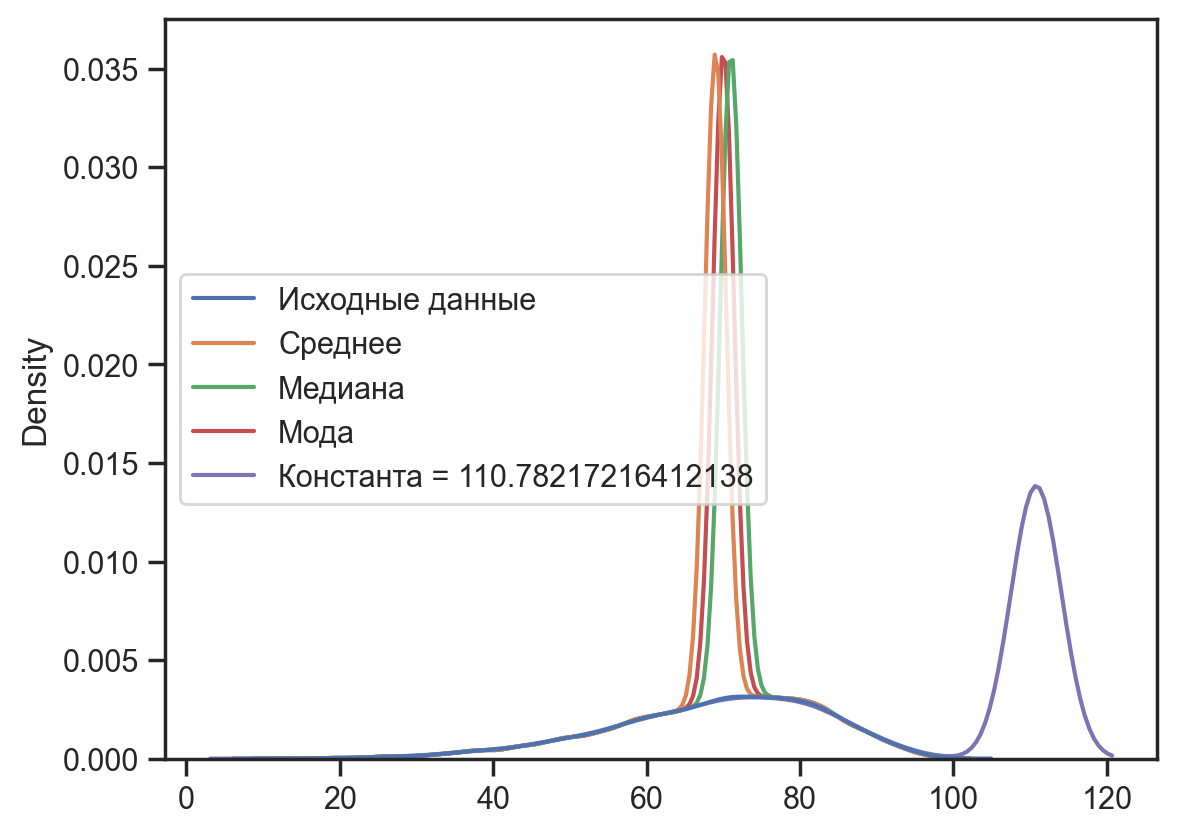

In [24]:
research_impute_numeric_column(data, 'Critic_Score', LotFrontage_ev)

In [25]:
LotFrontage_ev = data['Year_of_Release'].mean() + 3*data['Year_of_Release'].std()
LotFrontage_ev

np.float64(2024.1243399281452)

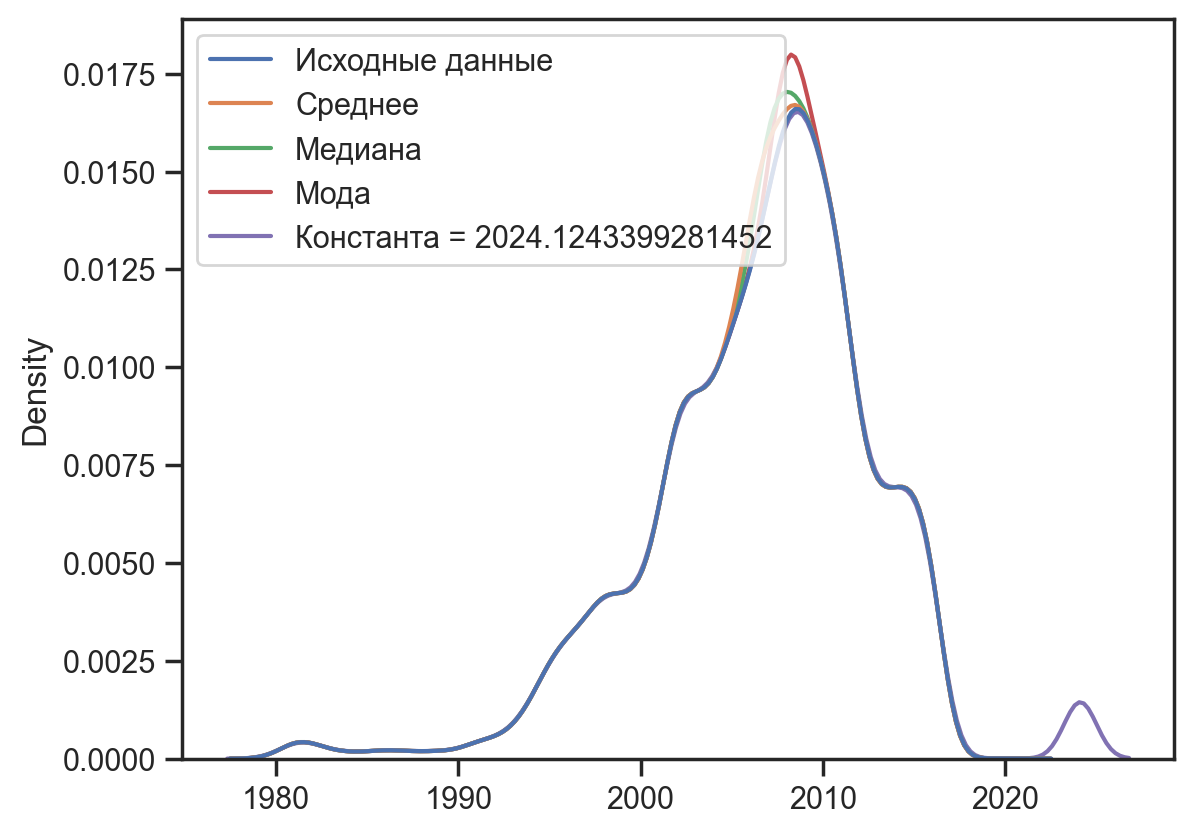

In [26]:
research_impute_numeric_column(data, 'Year_of_Release', LotFrontage_ev)

In [27]:
# Ассиметричное
IQR = data['User_Count'].quantile(0.75) - data['User_Count'].quantile(0.25)
MasVnrArea_ev1 = data['User_Count'].quantile(0.75) + 3*IQR
print('IQR={}, extreme_value={}'.format(IQR, MasVnrArea_ev1))

IQR=71.0, extreme_value=294.0


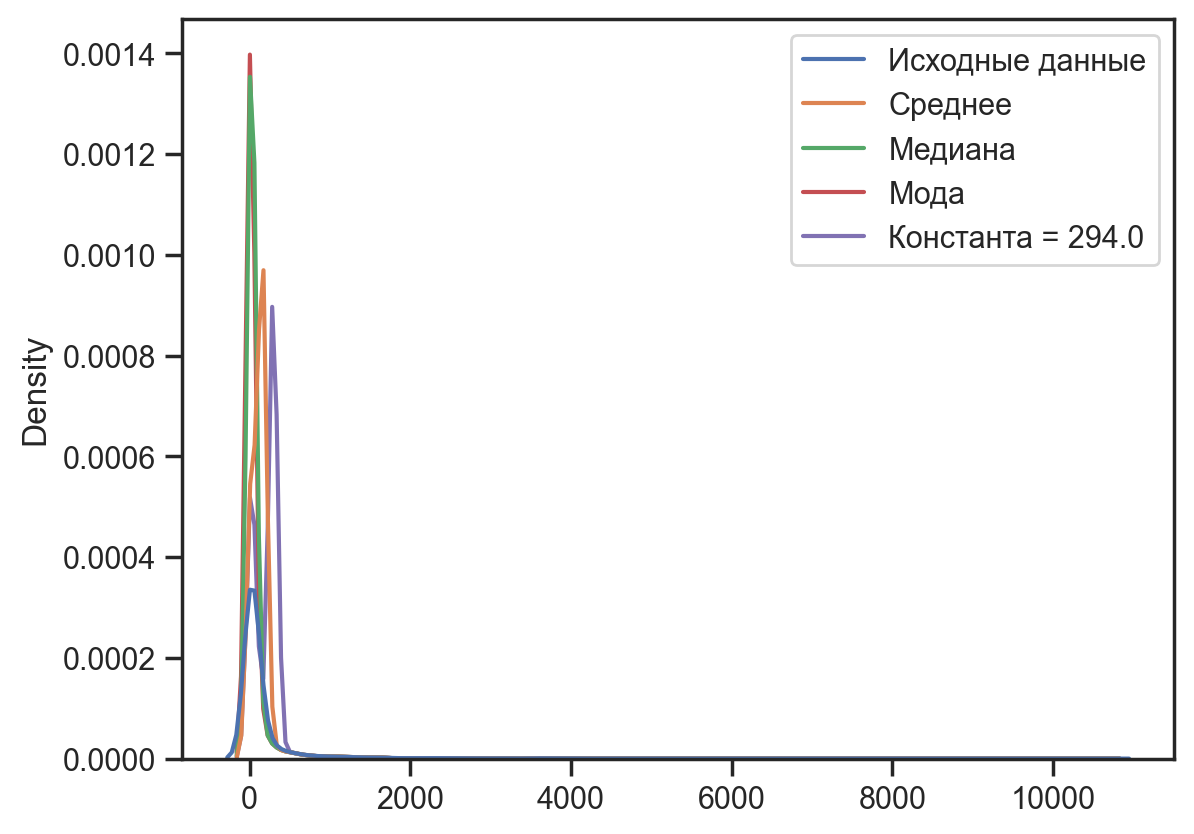

In [28]:
research_impute_numeric_column(data, 'User_Count', MasVnrArea_ev1)

## Обработка пропусков в категориальных данных  

### Выберем категориальные колонки с пропущенными значениями
### Цикл по колонкам датасета 

In [29]:
cat_cols = [] 
for col in data.columns:
     # Количество пустых значений  
    temp_null_count = data[data[col].isnull()].shape[0]  
    dt = str(data[col].dtype) 
    if temp_null_count>0 and (dt=='object') or (dt=='str'): 
        cat_cols.append(col) 
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений  {}, {}%.'.format(col, dt, temp_null_count, temp_perc)) 

Колонка Name. Тип данных str. Количество пустых значений  2, 0.01%.
Колонка Platform. Тип данных str. Количество пустых значений  0, 0.0%.
Колонка Genre. Тип данных str. Количество пустых значений  2, 0.01%.
Колонка Publisher. Тип данных str. Количество пустых значений  54, 0.32%.
Колонка User_Score. Тип данных str. Количество пустых значений  6704, 40.1%.
Колонка Developer. Тип данных str. Количество пустых значений  6623, 39.61%.
Колонка Rating. Тип данных str. Количество пустых значений  6769, 40.49%.


In [30]:
cat_temp_data = data[['Genre']] 
cat_temp_data.head() 

,Genre
0,Sports
1,Platform
2,Racing
3,Sports
4,Role-Playing


In [31]:
cat_temp_data['Genre'].unique() 

<StringArray>
[      'Sports',     'Platform',       'Racing', 'Role-Playing',
       'Puzzle',         'Misc',      'Shooter',   'Simulation',
       'Action',     'Fighting',    'Adventure',     'Strategy',
            nan]
Length: 13, dtype: str

In [32]:
cat_temp_data[cat_temp_data['Genre'].isnull()] 

,Genre
659,NaN
14246,NaN


In [33]:
# Импьютация наиболее частыми значениями 
imp2 = sklearn.impute.SimpleImputer(missing_values=np.nan,  strategy='most_frequent') 
data_imp2 = imp2.fit_transform(cat_temp_data) 
data_imp2

array([['Sports'],
       ['Platform'],
       ['Racing'],
       ...,
       ['Adventure'],
       ['Platform'],
       ['Simulation']], shape=(16719, 1), dtype=object)

In [34]:
# Пустые значения отсутствуют 
np.unique(data_imp2) 

array(['Action', 'Adventure', 'Fighting', 'Misc', 'Platform', 'Puzzle',
       'Racing', 'Role-Playing', 'Shooter', 'Simulation', 'Sports',
       'Strategy'], dtype=object)

In [35]:
# Импьютация константой 
imp3 = sklearn.impute.SimpleImputer(missing_values=np.nan,  strategy='constant', fill_value='NA') 
data_imp3 = imp3.fit_transform(cat_temp_data) 
data_imp3 

array([['Sports'],
       ['Platform'],
       ['Racing'],
       ...,
       ['Adventure'],
       ['Platform'],
       ['Simulation']], shape=(16719, 1), dtype=object)

In [36]:
np.unique(data_imp3) 

array(['Action', 'Adventure', 'Fighting', 'Misc', 'NA', 'Platform',
       'Puzzle', 'Racing', 'Role-Playing', 'Shooter', 'Simulation',
       'Sports', 'Strategy'], dtype=object)

In [37]:
data_imp3[data_imp3=='NA'].size 

2

In [38]:
data_imp2.reshape(1, 16719)

array([['Sports', 'Platform', 'Racing', ..., 'Adventure', 'Platform',
        'Simulation']], shape=(1, 16719), dtype=object)

In [39]:
data_imp2.tolist()[:10]

[['Sports'],
 ['Platform'],
 ['Racing'],
 ['Sports'],
 ['Role-Playing'],
 ['Puzzle'],
 ['Platform'],
 ['Misc'],
 ['Platform'],
 ['Shooter']]

In [40]:
data['Genre'] = data_imp2.ravel()
data['Genre'].unique() 

<StringArray>
[      'Sports',     'Platform',       'Racing', 'Role-Playing',
       'Puzzle',         'Misc',      'Shooter',   'Simulation',
       'Action',     'Fighting',    'Adventure',     'Strategy']
Length: 12, dtype: str

## Кодирование категориальных признаков

In [41]:
types=data["Genre"] 
types.value_counts() 

Genre
Action          3372
Sports          2348
Misc            1750
Role-Playing    1500
Shooter         1323
Adventure       1303
Racing          1249
Platform         888
Simulation       874
Fighting         849
Strategy         683
Puzzle           580
Name: count, dtype: int64

### Кодирование категорий целочисленными значениями - label  encoding 

In [42]:
le=sklearn.preprocessing.LabelEncoder() 
type_le=le.fit_transform(types) 
print(np.unique(type_le)) 
le.inverse_transform(np.unique(type_le))

[ 0  1  2  3  4  5  6  7  8  9 10 11]


array(['Action', 'Adventure', 'Fighting', 'Misc', 'Platform', 'Puzzle',
       'Racing', 'Role-Playing', 'Shooter', 'Simulation', 'Sports',
       'Strategy'], dtype=object)

### Pandas get_dummies - one-hot быстрый вариант кодирования 

In [43]:
type_s=pd.get_dummies(types) 
type_s.head(25) 

,Action,Adventure,Fighting,Misc,Platform,Puzzle,Racing,Role-Playing,Shooter,Simulation,Sports,Strategy
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,True,False,False,False,False,False,False,False
2,False,False,False,False,False,False,True,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,True,False,False,False,False
5,False,False,False,False,False,True,False,False,False,False,False,False
6,False,False,False,False,True,False,False,False,False,False,False,False
7,False,False,False,True,False,False,False,False,False,False,False,False
8,False,False,False,False,True,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,True,False,False,False


## Масштабирование данных

Масштабирование предполагает изменение диапазона измерения  величины а нормализация изменение распределения этой величины , - . 
Если признаки лежат в различных диапазонах то необходимо их ,  нормализовать Как правило применяют два следующих подхода . , :


### MinMax масштабирование

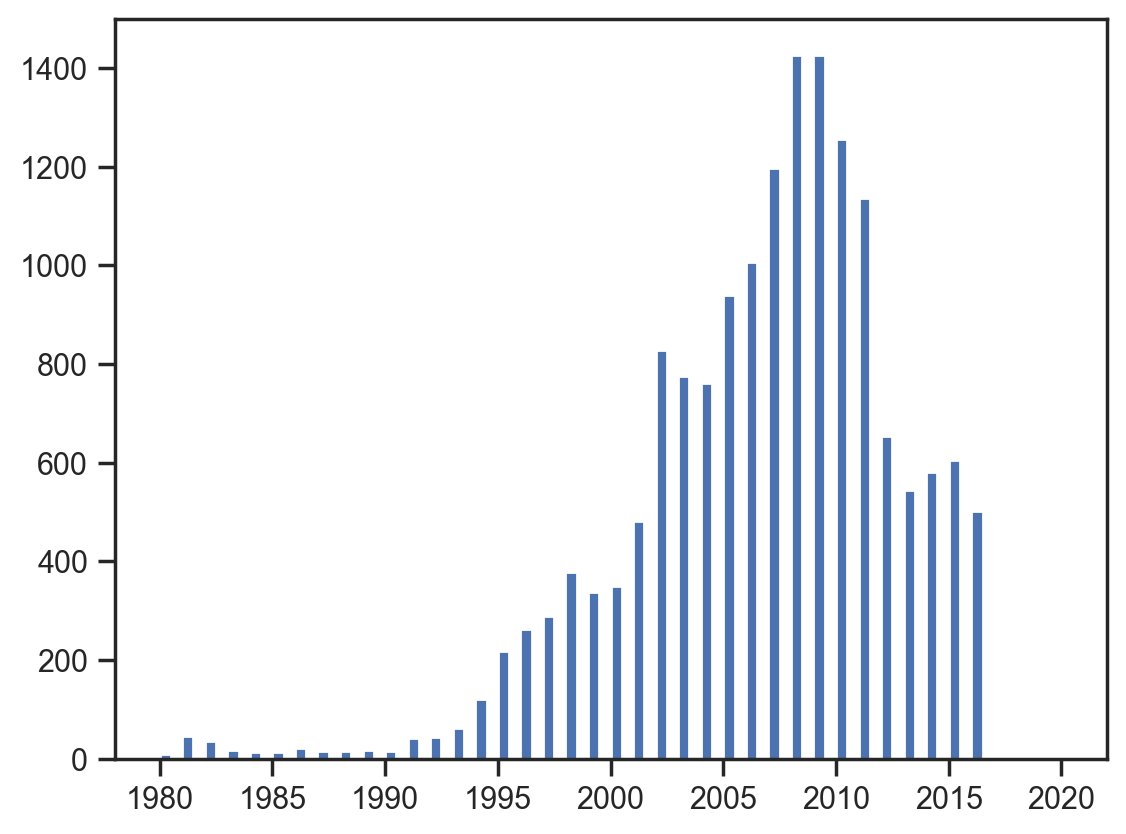

In [44]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler 
sc1 = MinMaxScaler() 
sc1_data = sc1.fit_transform(data[['Year_of_Release']]) 
plt.hist(data['Year_of_Release'], 80) 
plt.show() 

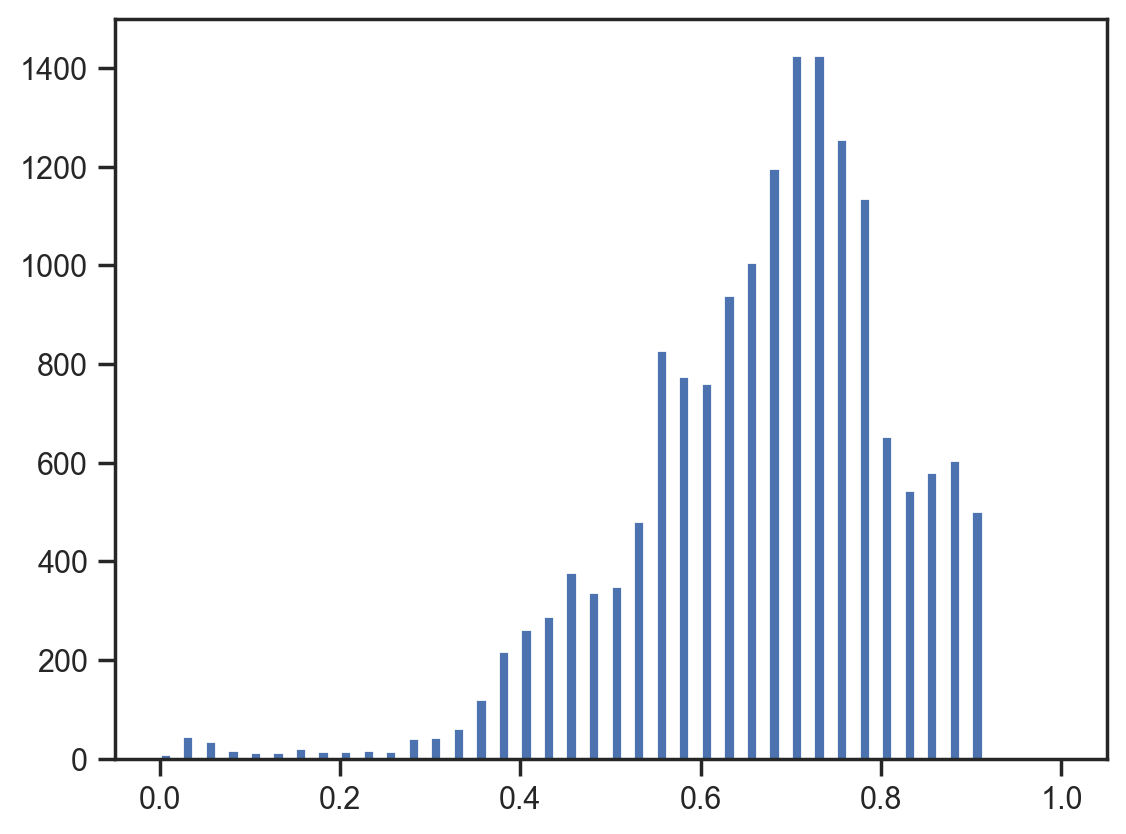

In [45]:
plt.hist(sc1_data, 80) 
plt.show() 

### Масштабирование данных на основе Z-оценки - StandardScaler 

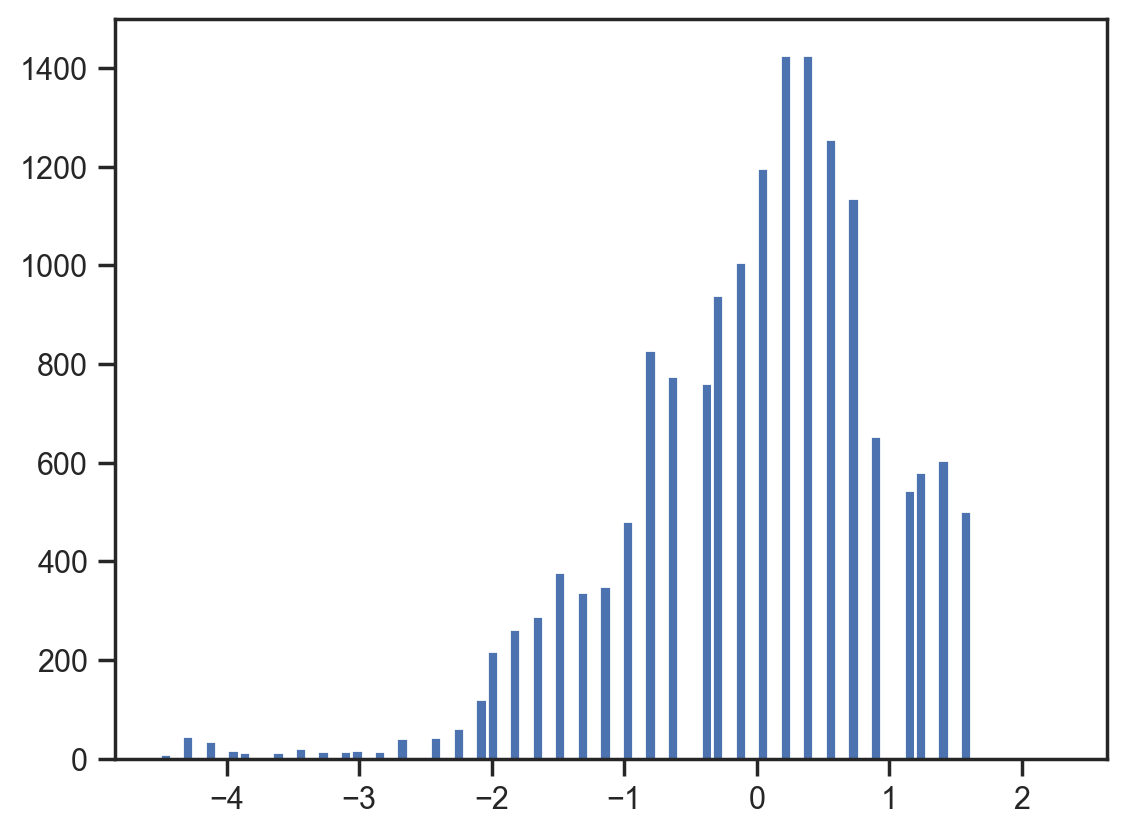

In [46]:
sc2 = StandardScaler() 
sc2_data = sc2.fit_transform(data[['Year_of_Release']]) 
plt.hist(sc2_data, 80) 
plt.show() 